In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import cv2

# For consistent results
torch.manual_seed(42)
np.random.seed(42)

class GeometricShapesDataset(Dataset):
    def __init__(self, num_samples_per_class=1000, img_size=28):
        self.img_size = img_size
        self.num_samples = num_samples_per_class * 3

        self.images = []
        self.labels = []

        # 0 = circle, 1 = square, 2 = triangle
        for i in range(num_samples_per_class):
            # Start with a black background
            circle_img = np.zeros((img_size, img_size), dtype=np.uint8)
            square_img = np.zeros((img_size, img_size), dtype=np.uint8)
            triangle_img = np.zeros((img_size, img_size), dtype=np.uint8)

            # Add random variation to position and size so it learns to generalize
            center = (img_size // 2 + np.random.randint(-2, 3), img_size // 2 + np.random.randint(-2, 3))
            radius = np.random.randint(7, 11)

            # Draw the circle
            cv2.circle(circle_img, center, radius, 255, -1)

            # Draw the square
            side = np.random.randint(12, 19)
            top_left = (center[0] - side // 2, center[1] - side // 2)
            bottom_right = (center[0] + side // 2, center[1] + side // 2)
            cv2.rectangle(square_img, top_left, bottom_right, 255, -1)

            # Draw the triangle
            pt1 = (center[0], center[1] - radius)
            pt2 = (center[0] - radius, center[1] + radius)
            pt3 = (center[0] + radius, center[1] + radius)
            pts = np.array([pt1, pt2, pt3], np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(triangle_img, [pts], 255)

            # Normalize images between -1 and 1 for GAN stability
            self.images.append((circle_img.astype(np.float32) / 127.5) - 1.0)
            self.labels.append(0)

            self.images.append((square_img.astype(np.float32) / 127.5) - 1.0)
            self.labels.append(1)

            self.images.append((triangle_img.astype(np.float32) / 127.5) - 1.0)
            self.labels.append(2)

        self.images = torch.tensor(np.array(self.images)).unsqueeze(1) # shape: [N, 1, 28, 28]
        self.labels = torch.tensor(np.array(self.labels), dtype=torch.long)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [8]:
class ConditionalGenerator(nn.Module):
    def __init__(self, num_classes=3, latent_dim=100, embed_dim=10, img_shape=(1, 28, 28)):
        super(ConditionalGenerator, self).__init__()
        self.img_shape = img_shape

        # Map class label to a continuous embedding space
        self.label_embed = nn.Embedding(num_classes, embed_dim)

        # Simple linear generator network
        self.network = nn.Sequential(
            nn.Linear(latent_dim + embed_dim, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, int(np.prod(img_shape))),
            nn.Tanh() # Projects output pixels directly to [-1, 1]
        )

    def forward(self, noise, labels):
        # Merge noise vector and label embedding together
        label_input = self.label_embed(labels)
        gen_input = torch.cat((noise, label_input), dim=-1)

        img_flat = self.network(gen_input)
        return img_flat.view(img_flat.size(0), *self.img_shape)

In [9]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=3, embed_dim=10, img_shape=(1, 28, 28)):
        super(ConditionalDiscriminator, self).__init__()
        self.img_shape = img_shape
        self.label_embed = nn.Embedding(num_classes, embed_dim)

        self.network = nn.Sequential(
            nn.Linear(int(np.prod(img_shape)) + embed_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid() # Outputs real/fake probability (0 to 1)
        )

    def forward(self, img, labels):
        # Flatten image and merge with label embedding
        img_flat = img.view(img.size(0), -1)
        label_input = self.label_embed(labels)

        disc_input = torch.cat((img_flat, label_input), dim=-1)
        return self.network(disc_input)

In [10]:
# Hyperparameters
LATENT_DIM = 100
BATCH_SIZE = 64
EPOCHS = 30
LR = 0.0002

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Init models
generator = ConditionalGenerator(num_classes=3, latent_dim=LATENT_DIM).to(device)
discriminator = ConditionalDiscriminator(num_classes=3).to(device)

# Standard GAN optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# Dataloader
dataset = GeometricShapesDataset(num_samples_per_class=1200)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Training loop
for epoch in range(EPOCHS):
    for i, (real_imgs, labels) in enumerate(dataloader):

        batch_size = real_imgs.size(0)
        real_imgs, labels = real_imgs.to(device), labels.to(device)

        # Ground truth targets
        real_target = torch.ones(batch_size, 1, device=device)
        fake_target = torch.zeros(batch_size, 1, device=device)


        #  Train Discriminator
        optimizer_D.zero_grad()

        # Loss on real images
        real_output = discriminator(real_imgs, labels)
        loss_real = criterion(real_output, real_target)

        # Generate fake images
        noise = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_imgs = generator(noise, labels)

        # Loss on fake images
        fake_output = discriminator(fake_imgs.detach(), labels)
        loss_fake = criterion(fake_output, fake_target)

        loss_D = (loss_real + loss_fake) / 2
        loss_D.backward()
        optimizer_D.step()

        #  Train Generator
        optimizer_G.zero_grad()

        # We want the discriminator to think fake images are real
        output = discriminator(fake_imgs, labels)
        loss_G = criterion(output, real_target)

        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Epoch [1/30] | D Loss: 0.4524 | G Loss: 0.9055
Epoch [2/30] | D Loss: 0.3663 | G Loss: 0.9373
Epoch [3/30] | D Loss: 0.2604 | G Loss: 1.7394
Epoch [4/30] | D Loss: 0.1611 | G Loss: 2.3932
Epoch [5/30] | D Loss: 0.1499 | G Loss: 1.8852
Epoch [6/30] | D Loss: 0.3308 | G Loss: 1.1697
Epoch [7/30] | D Loss: 0.1134 | G Loss: 2.6284
Epoch [8/30] | D Loss: 0.0950 | G Loss: 2.9732
Epoch [9/30] | D Loss: 0.4929 | G Loss: 1.1609
Epoch [10/30] | D Loss: 0.1483 | G Loss: 3.6710
Epoch [11/30] | D Loss: 0.0728 | G Loss: 3.0012
Epoch [12/30] | D Loss: 0.1815 | G Loss: 1.6109
Epoch [13/30] | D Loss: 0.2576 | G Loss: 3.2015
Epoch [14/30] | D Loss: 0.2154 | G Loss: 2.2619
Epoch [15/30] | D Loss: 0.6212 | G Loss: 0.4897
Epoch [16/30] | D Loss: 0.3688 | G Loss: 4.1136
Epoch [17/30] | D Loss: 0.2275 | G Loss: 1.8807
Epoch [18/30] | D Loss: 0.2520 | G Loss: 3.5054
Epoch [19/30] | D Loss: 0.4563 | G Loss: 0.5867
Epoch [20/30] | D Loss: 0.2500 | G Loss: 2.1064
Epoch [21/30] | D Loss: 0.2417 | G Loss: 1.6299
E

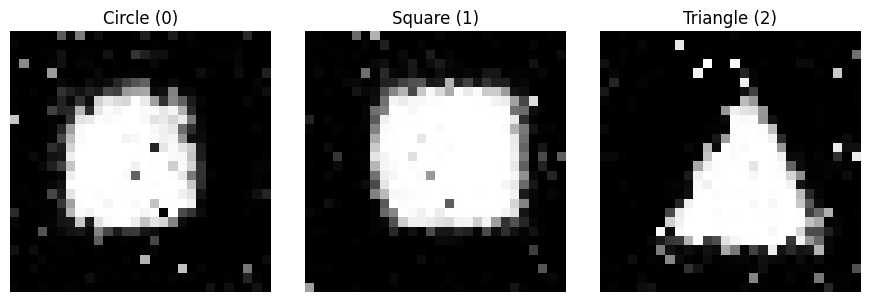

In [11]:
# Test generation
generator.eval()
with torch.no_grad():
    # Provide one sample for each category: 0, 1, 2
    test_labels = torch.tensor([0, 1, 2], dtype=torch.long, device=device)
    test_noise = torch.randn(3, LATENT_DIM, device=device)

    gen_imgs = generator(test_noise, test_labels).cpu()

    # Denormalize from [-1, 1] back to [0, 1] for plotting
    gen_imgs = (gen_imgs + 1.0) / 2.0

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    classes = ["Circle (0)", "Square (1)", "Triangle (2)"]

    for idx in range(3):
        axes[idx].imshow(gen_imgs[idx].squeeze(0).numpy(), cmap='gray')
        axes[idx].set_title(classes[idx])
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()